In [1]:
# !pip install albumentations transformers

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation
from tqdm import tqdm

# Check Apple Silicon (MPS) Availability
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using compute device: {device}")

Using compute device: mps


In [2]:
img_dir = "data/model_ready/images"
mask_dir = "data/model_ready/masks"
all_tiles = sorted(os.listdir(img_dir))

random.seed(42) 
random.shuffle(all_tiles)

split_idx = int(len(all_tiles) * 0.8)
train_files = all_tiles[:split_idx]
val_files = all_tiles[split_idx:]

print(f"Total tiles: {len(all_tiles)}")
print(f"Training tiles: {len(train_files)}")
print(f"Validation tiles: {len(val_files)}")

train_transform = A.Compose([
    A.Resize(1024, 1024), 
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2() 
])

val_transform = A.Compose([
    A.Resize(1024, 1024), 
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ToTensorV2() 
])

class UrbanHabitatDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = file_list # <-- We pass the specific split list here
        
    def __len__(self):
        return len(self.images)
        
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        
        with rasterio.open(img_path) as src_img:
            image = src_img.read()
            image = np.transpose(image, (1, 2, 0)) 
            
        with rasterio.open(mask_path) as src_mask:
            mask = src_mask.read(1)
            
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        mask = mask.to(torch.long)
        return image, mask

train_dataset = UrbanHabitatDataset(img_dir, mask_dir, file_list=train_files, transform=train_transform)
val_dataset = UrbanHabitatDataset(img_dir, mask_dir, file_list=val_files, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0) 

print("Train and Validation DataLoaders successfully created!")

Total tiles: 100
Training tiles: 80
Validation tiles: 20
Train and Validation DataLoaders successfully created!


In [3]:
# Define mapping
id2label = {
    0: 'Impervious / Built-up',
    1: 'Forest & Dense Canopy',
    2: 'Urban Trees & Bushes',
    3: 'Managed Green Spaces',
    4: 'Standard Grassland',
    5: 'Ecologically Valuable Meadow',
    6: 'Agriculture & Orchards',
    7: 'Water Bodies'
}
label2id = {v: k for k, v in id2label.items()}

# Initialize SegFormer
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

print("\nModel successfully initialized on the compute device.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta


Model successfully initialized on the compute device.


In [4]:
# mIoU Calculation Function
def calculate_iou(preds, labels, num_classes, ignore_index=255):
    ious = []
    preds = preds.view(-1)
    labels = labels.view(-1)
    
    valid_mask = (labels != ignore_index)
    preds = preds[valid_mask]
    labels = labels[valid_mask]
    
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (labels == cls)
        
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        
        if union > 0:
            ious.append(intersection / union)
            
    return sum(ious) / len(ious) if ious else 0.0

# Focal Loss Implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ignore_index=255):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
        self.ce = nn.CrossEntropyLoss(weight=alpha, ignore_index=ignore_index, reduction='none')

    def forward(self, logits, targets):
        log_pt = self.ce(logits, targets)
        pt = torch.exp(-log_pt)
        focal_loss = ((1 - pt) ** self.gamma) * log_pt
        return focal_loss.mean()

# Setup V3 Optimizer, Scheduler, and FOCAL LOSS
weights = torch.tensor([1.0, 5.0, 2.0, 2.0, 5.0, 3.0, 10.0, 10.0]).float().to(device)
loss_fn = FocalLoss(alpha=weights, gamma=2.0, ignore_index=255)

optimizer = optim.AdamW(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

epochs = 30
patience = 5
best_miou = 0.0
epochs_no_improve = 0

history_train_loss = []
history_val_miou = []

print(f"Starting training on {device} with Focal Loss & Scheduler...")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Current Learning Rate: {optimizer.param_groups[0]['lr']}")
    
    # TRAINING PHASE
    model.train()
    running_loss = 0.0
    for images, masks in tqdm(train_loader, desc="Training Batches"):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(pixel_values=images)
        
        upsampled_logits = F.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        
        loss = loss_fn(upsampled_logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    history_train_loss.append(avg_loss)
    print(f"Average Training Loss: {avg_loss:.4f}")
    
    # VALIDATION PHASE
    model.eval()
    running_miou = 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation Batches"):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(pixel_values=images)
            
            upsampled_logits = F.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
            preds = upsampled_logits.argmax(dim=1)
            
            batch_miou = calculate_iou(preds, masks, num_classes=8)
            running_miou += batch_miou
            
    avg_miou = running_miou / len(val_loader)
    history_val_miou.append(avg_miou)
    print(f"Validation mIoU: {avg_miou * 100:.2f}%")
    
    # SCHEDULER & EARLY STOPPING
    scheduler.step(avg_miou)
    
    if avg_miou > best_miou:
        best_miou = avg_miou
        epochs_no_improve = 0
        os.makedirs("models/best_prototype_v3", exist_ok=True)
        model.save_pretrained("models/best_prototype_v3") 
        print("New best Validation accuracy! Model saved.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")
        
    if epochs_no_improve >= patience:
        print(f"\n Early stopping triggered! Best mIoU was {best_miou * 100:.2f}%")
        break

print("\n Training Complete!")

Starting V3 training on mps with Focal Loss & Scheduler...

Epoch 1/30
Current Learning Rate: 0.0001


Training Batches: 100%|█████████████████████████| 20/20 [00:11<00:00,  1.72it/s]


Average Training Loss: 3.2724


Validation Batches: 100%|█████████████████████████| 5/5 [00:01<00:00,  3.12it/s]

Validation mIoU: 0.48%


...

Validation mIoU: 11.27%
No improvement for 4 epochs.

Epoch 10/30
Current Learning Rate: 5e-05


Training Batches: 100%|█████████████████████████| 20/20 [00:11<00:00,  1.75it/s]


Average Training Loss: 2.8923


Validation Batches: 100%|█████████████████████████| 5/5 [00:01<00:00,  3.07it/s]

Validation mIoU: 11.27%
No improvement for 5 epochs.

 Early stopping triggered! Best mIoU was 11.27%

 Training Complete!


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

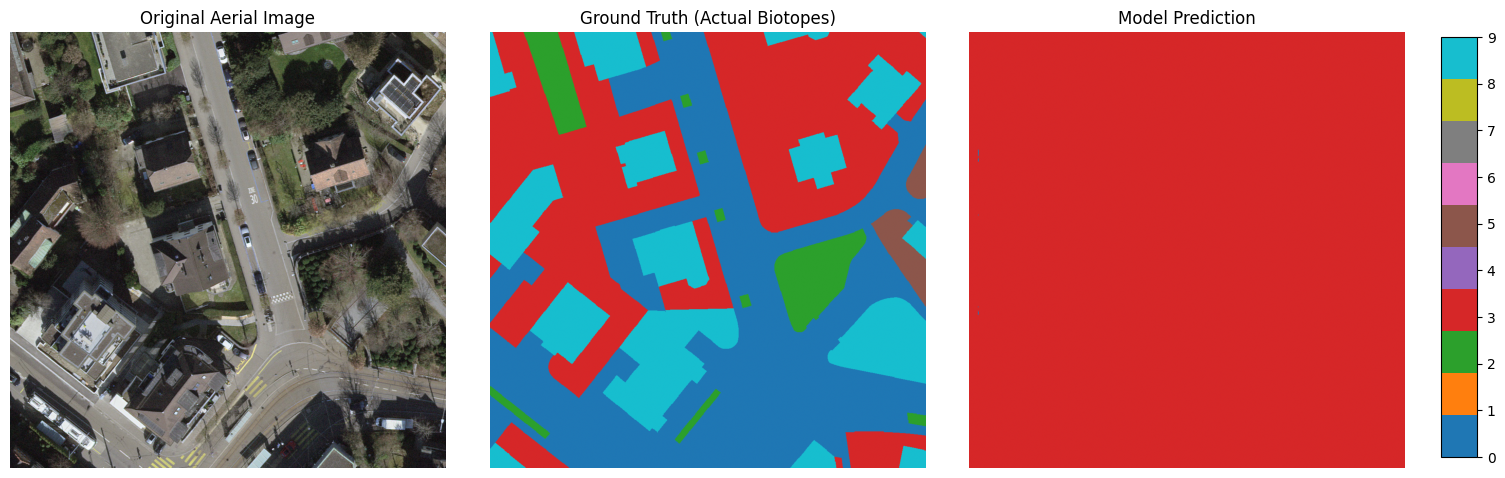

In [7]:
# Load the best model weights we just saved
model = SegformerForSemanticSegmentation.from_pretrained("models/best_prototype").to(device)
model.eval()

# Grab a single batch
images, masks = next(iter(train_loader))
input_image = images[0].unsqueeze(0).to(device)
ground_truth = masks[0].numpy()

with torch.no_grad():
    outputs = model(pixel_values=input_image)
    logits = F.interpolate(
        outputs.logits, size=(1024, 1024), mode="bilinear", align_corners=False
    )
    predicted_mask = logits.argmax(dim=1).squeeze(0).cpu().numpy()

# Reverse normalization for plotting
img_display = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_display)
axs[0].set_title("Original Aerial Image")
axs[0].axis('off')

axs[1].imshow(ground_truth, cmap='tab10', vmin=0, vmax=9)
axs[1].set_title("Ground Truth (Actual Biotopes)")
axs[1].axis('off')

im = axs[2].imshow(predicted_mask, cmap='tab10', vmin=0, vmax=9)
axs[2].set_title("Model Prediction")
axs[2].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
fig.colorbar(im, cax=cbar_ax)
plt.subplots_adjust(wspace=0.1, right=0.9)
plt.show()

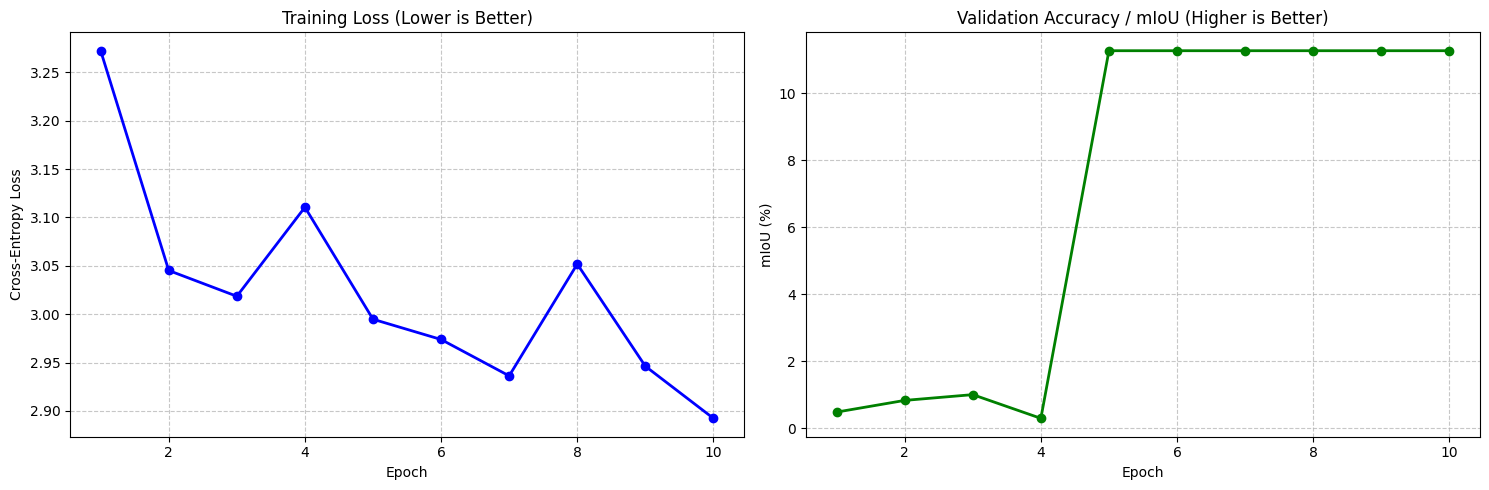

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Training Loss
ax1.plot(range(1, len(history_train_loss) + 1), history_train_loss, marker='o', color='b', linewidth=2)
ax1.set_title("Training Loss (Lower is Better)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Validation mIoU
ax2.plot(range(1, len(history_val_miou) + 1), [m * 100 for m in history_val_miou], marker='o', color='g', linewidth=2)
ax2.set_title("Validation Accuracy / mIoU (Higher is Better)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("mIoU (%)")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()